<a href="https://colab.research.google.com/github/underratedicon/python-practice/blob/main/ANN_for_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

In [2]:
data = pd.read_csv('gila_river.csv')

In [3]:
data.head()

,y(t-1),y(t-2),y(t-3),y(t)
0,0.0,0.0,0.0,32.0
1,32.0,0.0,0.0,27.0
2,27.0,32.0,0.0,27.0
3,27.0,27.0,32.0,25.0
4,25.0,27.0,27.0,27.0


In [4]:
data.shape

(1034, 4)

In [5]:
X = data.drop(columns=['y(t)'])
y = data['y(t)']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
mlp = MLPRegressor(hidden_layer_sizes=(64,64), max_iter=3000, random_state=42)

In [9]:
mlp.fit(X_train, y_train)

MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=3000, random_state=42)

In [10]:
y_train_pred = mlp.predict(X_train)
y_test_pred = mlp.predict(X_test)

In [11]:
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

In [12]:
print(f"Training MSE: {mse_train}")
print(f"Testing MSE: {mse_test}")

Training MSE: 61200.11502134433
Testing MSE: 24308.48773391334


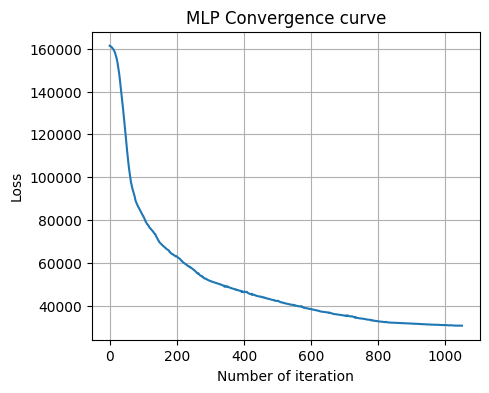

In [13]:
plt.figure(figsize=(5, 4))
plt.plot(mlp.loss_curve_)
plt.title('MLP Convergence curve')
plt.xlabel('Number of iteration')
plt.ylabel('Loss')
plt.grid(True)

plt.show()

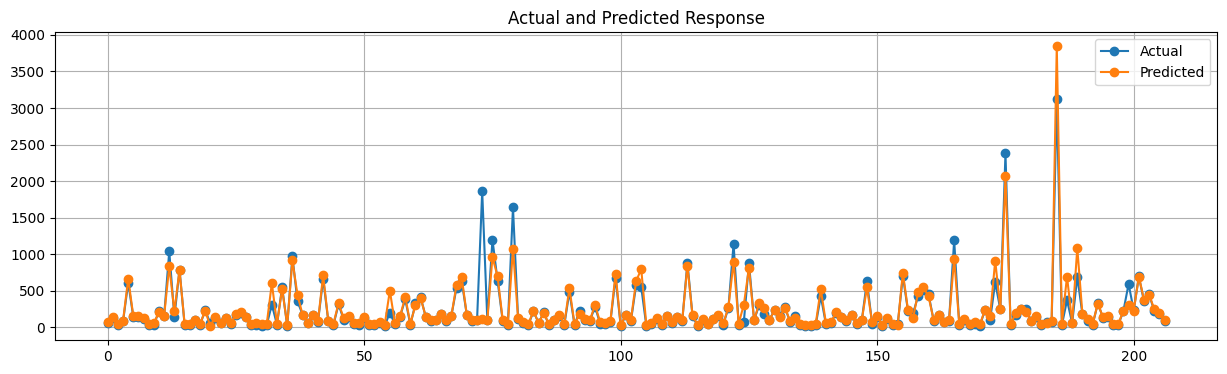

In [15]:
t = range(len(y_test))

plt.figure(figsize=(15,4))
plt.plot(t, y_test, label='Actual', linestyle='-', marker='o')
plt.plot(t, y_test_pred, label='Predicted', linestyle='-', marker='o')
plt.title('Actual and Predicted Response')
plt.legend()
plt.grid(True)

plt.show()

/tmp/ipykernel_29494/495557919.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


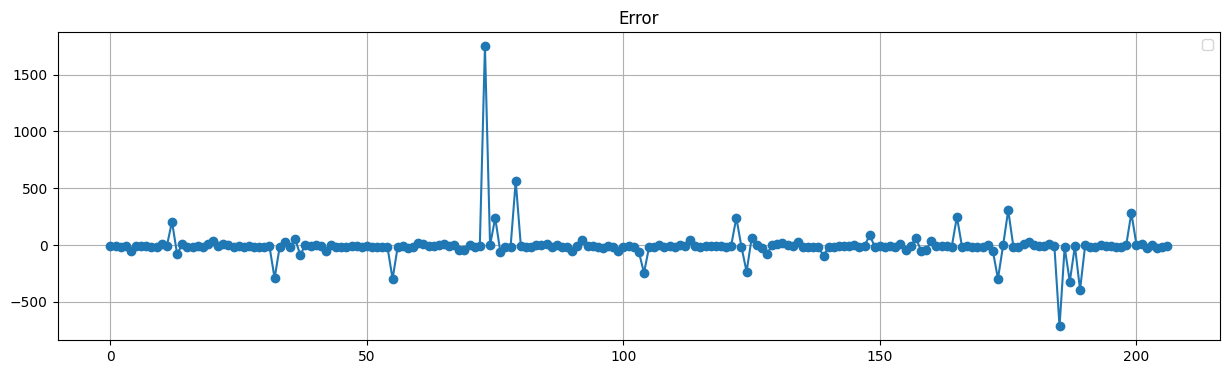

In [16]:
t = range(len(y_test))

plt.figure(figsize=(15,4))
plt.plot(t, y_test - y_test_pred, linestyle='-', marker='o')
plt.title('Error')
plt.legend()
plt.grid(True)

plt.show()

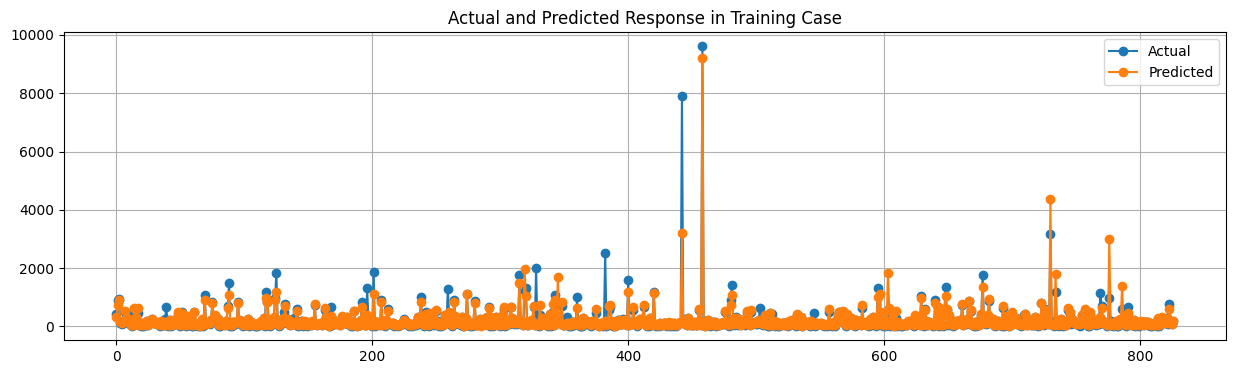

In [17]:
t = range(len(y_train))

plt.figure(figsize=(15,4))
plt.plot(t, y_train, label='Actual', linestyle='-', marker='o')
plt.plot(t, y_train_pred, label='Predicted', linestyle='-', marker='o')
plt.title('Actual and Predicted Response in Training Case')
plt.legend()
plt.grid(True)

plt.show()